<a href="https://colab.research.google.com/github/jaeho0726/Sentiment-Analysis/blob/main/konlpy_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Import Libraries and Configuration**

In [1]:
!pip install -q konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 25.4 MB/s eta 0:00:00


In [2]:
import re

import urllib.request
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_style("white")

import tqdm

from konlpy.tag import Okt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import json
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json

from sklearn.metrics import mean_absolute_error, mean_squared_error

from scipy.stats import pearsonr

## **2. NSMC Training Data Preparation**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = '/content/drive/MyDrive/Project/Sentiment_Analysis/konlpy_model'

Mounted at /content/drive


In [4]:
TOKENIZER_PATH = os.path.join(MODEL_PATH, 'tokenizer.json')
CONFIG_PATH = os.path.join(MODEL_PATH, 'config.json')
KERAS_PATH = os.path.join(MODEL_PATH, 'lstm_model.keras')

MODEL_EXISTS = all([
    os.path.exists(TOKENIZER_PATH),
    os.path.exists(CONFIG_PATH),
    os.path.exists(KERAS_PATH)
])

if not MODEL_EXISTS:
  # Accessing Naver movie review data
  train_file = urllib.request.urlopen("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt")
  test_file = urllib.request.urlopen("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt")
  train_data = pd.read_table(train_file)
  test_data = pd.read_table(test_file)

  # Cleaning train data
  train_data.drop_duplicates(subset=['document'], inplace = True)
  train_data = train_data.dropna(how='any')
  train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)
  train_data['document'] = train_data['document'].replace('', np.nan)
  train_data = train_data.dropna(how='any')

  # Cleaning test data
  test_data.drop_duplicates(subset=['document'], inplace = True)
  test_data = test_data.dropna(how='any')
  test_data['document'] = test_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)
  test_data['document'] = test_data['document'].replace('', np.nan)
  test_data = test_data.dropna(how='any')

  print("NSMC data loaded and cleaned")

else:
  print("Save model found - skipping NSMC data loading")

Save model found - skipping NSMC data loading


## **3. KoNLPy Model**

In [5]:
import json
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json

okt = Okt()
stopwords = ['의', '가', '이', '은', '들', '는', '좀', '잘', '과', '도', '를', '으로', '자', '에', '와', '한', '하다']

TOKENIZER_PATH = os.path.join(MODEL_PATH, 'tokenizer.json')
CONFIG_PATH    = os.path.join(MODEL_PATH, 'config.json')
KERAS_PATH     = os.path.join(MODEL_PATH, 'lstm_model.keras')

if MODEL_EXISTS:
  # ── Load saved model, tokenizer, and config ──────────────────────────
  with open(TOKENIZER_PATH, 'r', encoding='utf-8') as f:
      tokenizer = tokenizer_from_json(f.read())

  with open(CONFIG_PATH, 'r') as f:
      config = json.load(f)
  vocab_size = config['vocab_size']
  max_len    = config['max_len']

  model = load_model(KERAS_PATH)
  print("Saved model loaded from", MODEL_PATH)

else:
  # ── Tokenization ─────────────────────────────────────────────────────
  X_train = []
  for sentence in tqdm.tqdm(train_data['document']):
      X_train.append([word for word in okt.morphs(sentence) if word not in stopwords])

  X_test = []
  for sentence in tqdm.tqdm(test_data['document']):
      X_test.append([word for word in okt.morphs(sentence) if word not in stopwords])

  # ── Vocabulary and rare word removal ─────────────────────────────────
  tokenizer = Tokenizer()
  tokenizer.fit_on_texts(X_train)

  threshold  = 3
  rare_count = sum(1 for v in tokenizer.word_counts.values() if v < threshold)
  vocab_size = len(tokenizer.word_index) - rare_count + 2
  max_len    = 60

  tokenizer = Tokenizer(vocab_size, oov_token='OOV')
  tokenizer.fit_on_texts(X_train)
  X_train = tokenizer.texts_to_sequences(X_train)
  X_test  = tokenizer.texts_to_sequences(X_test)

  y_train = np.array(train_data['label'])
  y_test  = np.array(test_data['label'])

  # Drop empty sequences
  drop_train = [i for i, s in enumerate(X_train) if len(s) < 1]
  X_train = [s for i, s in enumerate(X_train) if i not in drop_train]
  y_train = np.delete(y_train, drop_train, axis=0)

  X_train = pad_sequences(X_train, maxlen=max_len)
  X_test  = pad_sequences(X_test,  maxlen=max_len)

  # ── Build and train model ─────────────────────────────────────────────
  from tensorflow.keras.layers import Embedding, Dense, LSTM, Bidirectional
  from tensorflow.keras.callbacks import EarlyStopping
  from tensorflow.keras.models import Sequential

  model = Sequential()
  model.add(Embedding(vocab_size, 100, input_length=max_len))
  model.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
  model.summary()

  early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
  history = model.fit(X_train, y_train, epochs=10, batch_size=256,
                      validation_split=0.2, callbacks=[early_stop])
  test_loss, test_accuracy = model.evaluate(
  X_test,
  y_test,
  verbose=0)

  # ── Save model, tokenizer, and config ─────────────────────────────────
  os.makedirs(MODEL_PATH, exist_ok=True)

  model.save(KERAS_PATH)

  with open(TOKENIZER_PATH, 'w', encoding='utf-8') as f:
      f.write(tokenizer.to_json())

  with open(CONFIG_PATH, 'w') as f:
      json.dump({'vocab_size': vocab_size, 'max_len': max_len}, f)

  print("Training complete. Model saved to", MODEL_PATH)

Saved model loaded from /content/drive/MyDrive/Project/Sentiment_Analysis/konlpy_model


## **4. Daily Reflection Sentiment Inference**

In [6]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

creds, _ = default()

gc = gspread.Client(auth=creds)

spreadsheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/1DrDCLitpXZyJajcWYcMNcJCZU4Xa0aE_gj4sfXzl6x4/edit?gid=0#gid=0')

worksheet = spreadsheet.worksheet('data')

In [7]:
df = pd.DataFrame(worksheet.get_all_records())

# Shortening Column Names
df = df.rename(columns={
    "Work Intensity (0 - Easy / 10 - Intense)": "Work Intensity",
    "Overall Mood (0 - Poor / 10 - Great)": "Overall Mood",
    "Name": "Date"
})

# Fixing Data Types
df["Hours of Work"] = pd.to_numeric(df["Hours of Work"], errors="coerce").fillna(0)
df["Work Intensity"] = pd.to_numeric(df["Work Intensity"], errors="coerce").fillna(0)
df["Overall Mood"] = pd.to_numeric(df["Overall Mood"], errors="coerce")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df['Day of Week'] = df['Date'].dt.day_name()


df[[
      "Date",
      "Today's Status",
      "Hours of Work",
      "Work Intensity",
      "Overall Mood",
      "Day of Week"
    ]
].head()

,Date,Today's Status,Hours of Work,Work Intensity,Overall Mood,Day of Week
0,2026-01-24,On Duty,0.0,0,9,Saturday
1,2026-01-25,On Duty,2.5,2,6,Sunday
2,2026-01-26,On Duty,8.0,1,6,Monday
3,2026-01-27,On Duty,8.0,1,5,Tuesday
4,2026-01-28,On Duty,7.0,1,7,Wednesday


In [8]:
def predict_reflection_sentiment(reflection):
  if not isinstance(reflection, str) or len(reflection.strip()) == 0:
      return None

  sentences = [
      s.strip()
      for s in re.split(r'[.!?]', reflection)
      if len(s.strip()) > 0
  ]

  if len(sentences) == 0:
      return None

  weighted_scores = []
  total_tokens = 0

  for sentence in sentences:
      try:
          tokens = [
              word
              for word in okt.morphs(sentence)
              if word not in stopwords
          ]

          if len(tokens) == 0:
              continue

          padded_sequence = pad_sequences(
              tokenizer.texts_to_sequences([tokens]),
              maxlen=max_len
          )

          probability = float(
              model.predict(
                  padded_sequence,
                  verbose=0
              )[0][0]
          )

          token_count = len(tokens)

          weighted_scores.append(
              probability * token_count
          )

          total_tokens += token_count

      except Exception:
          continue

  if total_tokens == 0:
      return None

  weighted_probability = (sum(weighted_scores) / total_tokens)

  return round(weighted_probability * 10, 2)

In [9]:
df['Sentiment Score'] = df['Reflection'].apply(predict_reflection_sentiment)

df['Sentiment Score'] = pd.to_numeric(df['Sentiment Score'], errors='coerce')

df[[
      "Date",
      "Today's Status",
      "Hours of Work",
      "Work Intensity",
      "Overall Mood",
      "Day of Week",
      "Sentiment Score"
    ]
].head()

,Date,Today's Status,Hours of Work,Work Intensity,Overall Mood,Day of Week,Sentiment Score
0,2026-01-24,On Duty,0.0,0,9,Saturday,6.16
1,2026-01-25,On Duty,2.5,2,6,Sunday,6.50
2,2026-01-26,On Duty,8.0,1,6,Monday,7.40
3,2026-01-27,On Duty,8.0,1,5,Tuesday,5.34
4,2026-01-28,On Duty,7.0,1,7,Wednesday,5.11


## **5. Validation Against Self-Reported Mood**

### **5.1 Alignment Metrics**

In [10]:
evaluation_df = df.dropna(
  subset=["Sentiment Score", "Overall Mood"]
).copy()

evaluation_df["Residual"] = (evaluation_df["Sentiment Score"] - evaluation_df["Overall Mood"])

evaluation_df["Absolute Discrepancy"] = (evaluation_df["Residual"].abs())

mae = mean_absolute_error(
  evaluation_df["Overall Mood"],
  evaluation_df["Sentiment Score"]
)

rmse = np.sqrt(
  mean_squared_error(
      evaluation_df["Overall Mood"],
      evaluation_df["Sentiment Score"]
  )
)

mean_bias = evaluation_df["Residual"].mean()

print(f"Mean Absolute Discrepancy (MAE): " f"{mae:.3f}")

print(f"RMSE: {rmse:.3f}")

print(f"Mean Bias: {mean_bias:.3f}")

Mean Absolute Discrepancy (MAE): 2.029
RMSE: 2.401
Mean Bias: -1.518


In [11]:
correlation, p_value = pearsonr(evaluation_df["Overall Mood"], evaluation_df["Sentiment Score"])

print(
    f"Pearson Correlation: "
    f"{correlation:.3f}"
)

print(
    f"P-value: "
    f"{p_value:.4f}"
)

Pearson Correlation: 0.196
P-value: 0.0260


### **5.2 Mood vs Sentiment Score Plot**

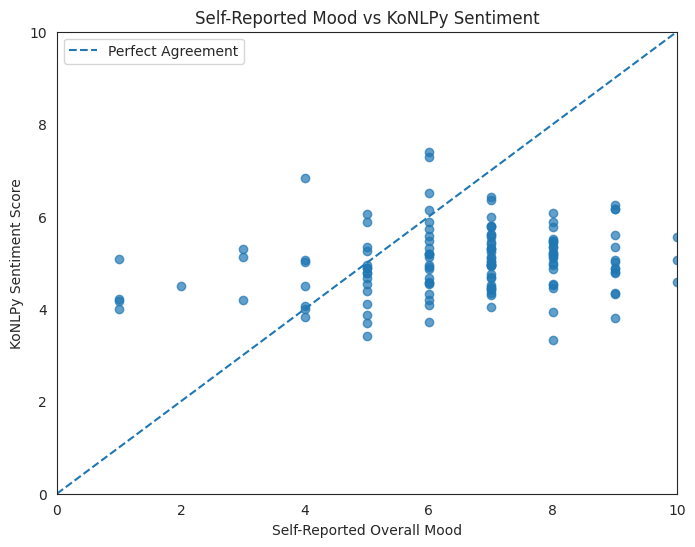

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    evaluation_df["Overall Mood"],
    evaluation_df["Sentiment Score"],
    alpha=0.7
)

plt.plot(
    [0, 10],
    [0, 10],
    linestyle="--",
    label="Perfect Agreement"
)

plt.xlim(0, 10)
plt.ylim(0, 10)

plt.xlabel("Self-Reported Overall Mood")
plt.ylabel("KoNLPy Sentiment Score")
plt.title("Self-Reported Mood vs KoNLPy Sentiment")

plt.legend()
plt.show()

### **5.3 Largest Discrepancies**

In [13]:
largest_discrepancies = (
  evaluation_df[
      [
          "Date",
          "Overall Mood",
          "Sentiment Score",
          "Absolute Discrepancy"
      ]
  ]
  .sort_values(
      "Absolute Discrepancy",
      ascending=False
  )
  .head(10)
)

largest_discrepancies

,Date,Overall Mood,Sentiment Score,Absolute Discrepancy
10,2026-02-03,10,4.58,5.42
117,2026-05-31,9,3.80,5.20
13,2026-02-06,10,5.05,4.95
27,2026-02-21,8,3.32,4.68
66,2026-04-04,9,4.33,4.67
77,2026-04-18,9,4.34,4.66
75,2026-04-15,10,5.55,4.45
128,2026-06-13,9,4.78,4.22
67,2026-04-05,9,4.79,4.21
127,2026-06-14,9,4.86,4.14
